<a href="https://colab.research.google.com/github/Prashkov1ch/python-ai-Prashkovich-Anna/blob/main/viz2_sea_wordcloud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

[0] Подготовка данных: клонирование репозитория и загрузка CSV (моря и океаны)
Что делаем:

Клонируем GitHub-репозиторий python-ai-Prashkovich-Anna в Google Colab

Загружаем CSV-файл seas-square-ocean-named after.csv (214 исходных записей о 182 уникальных морях)

Очищаем столбцы:

Переименовываем sea → URL (Wikidata ID, сохраняем для верификации)

Переименовываем seaLabel → sea (название моря на русском)

Переименовываем oceanLabel → ocean (принадлежность к океану)

Переименовываем named_afterLabel → named_after (объект, в честь которого названо море)

Приводим числовые поля (area, depth) к числовому типу (NaN остаётся NaN — не заменяем на 0!)

Удаляем дубликаты по URL (было 214 строк → осталось 182 уникальных моря)

In [1]:
# 📥 [0] Клонирование репозитория и загрузка данных (для вашего датасета о морях)

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Шаг 1: Клонируем ваш репозиторий
github_user = "Prashkov1ch"  # Ваш GitHub username (из вашего ноутбука)
repo = "python-ai-Prashkovich-Anna"  # Ваш репозиторий

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем ВАШ CSV-файл с данными о морях
# Обратите внимание: в имени файла есть пробел — это нормально
csv_filename = "data/seas-square-ocean-named after.csv"
df_oceans_raw = pd.read_csv(csv_filename)
print(f"📊 Загружено строк в df_oceans_raw: {len(df_oceans_raw)}")
print(f"📊 Исходные колонки: {df_oceans_raw.columns.tolist()}\n")

# Шаг 3: Очистка данных (как в вашем ноутбуке, но без дублирования)
# 3.1 Переименовываем технические столбцы
df_oceans_clean = df_oceans_raw.rename(columns={
    "sea": "URL",                    # Wikidata ID → URL
    "seaLabel": "sea",               # Название моря
    "oceanLabel": "ocean",           # Принадлежность к океану
    "named_afterLabel": "named_after"  # Источник названия
})

print("✅ Столбцы переименованы:")
print(f"   Новые колонки: {', '.join(df_oceans_clean.columns)}\n")

# 3.2 Преобразуем числовые столбцы (БЕЗ fillna(0) — оставляем NaN)
df_oceans_clean["area"] = pd.to_numeric(df_oceans_clean["area"], errors="coerce")
df_oceans_clean["depth"] = pd.to_numeric(df_oceans_clean["depth"], errors="coerce")
print("✅ Числовые столбцы 'area' и 'depth' преобразованы (NaN сохранён)\n")

# Шаг 4: Создаём выборки для анализа (как в вашем ноутбуке)
# 4.1 Убираем дубликаты по URL (оставляем уникальные моря)
df_unique = df_oceans_clean.drop_duplicates(subset="URL")
print(f"📊 Уникальных морей (по URL): {len(df_unique)}")
print(f"   (Было строк: {len(df_oceans_clean)}, дубликатов: {len(df_oceans_clean) - len(df_unique)})\n")

# 4.2 Выборки для графиков
df_area = df_unique[df_unique["area"].notna()].copy()
df_depth = df_unique[df_unique["depth"].notna()].copy()
df_named = df_unique[df_unique["named_after"].notna()].copy()

print("📊 АНАЛИТИЧЕСКИЕ ВЫБОРКИ:")
print(f"   • Морей с известной площадью (df_area): {len(df_area)}")
print(f"   • Морей с известной глубиной (df_depth): {len(df_depth)}")
print(f"   • Морей с известным источником названия (df_named): {len(df_named)}")
print(f"   • Всего уникальных морей (df_unique): {len(df_unique)}\n")

# Краткий обзор структуры данных
print("📋 СТРУКТУРА ДАННЫХ:")
print(f"   Столбцы в df_unique: {', '.join(df_unique.columns)}")
print(f"\n   Статистика пропусков (NaN) в df_unique:")
for col in df_unique.columns:
    null_count = df_unique[col].isna().sum()
    if null_count > 0:
        print(f"      • {col}: {null_count} пропусков ({null_count/len(df_unique)*100:.1f}%)")
    else:
        print(f"      • {col}: ✅ без пропусков")

print(f"\n🔍 ПРИМЕРЫ ДАННЫХ (первые 3 моря):")
print(df_unique[['sea', 'ocean', 'area', 'depth', 'named_after']].head(3).to_string(index=False))

print(f"\n📈 БАЗОВАЯ СТАТИСТИКА по числовым столбцам (df_unique):")
print(df_unique[['area', 'depth']].describe().round(2))

print("\n✅ Данные успешно загружены и подготовлены к анализу!")
print("="*60)
print("📌 Доступные DataFrame'ы:")
print("   • df_unique  — все уникальные моря (182 строки)")
print("   • df_area    — моря с известной площадью (42 строки)")
print("   • df_depth   — моря с известной глубиной (49 строк)")
print("   • df_named   — моря с известным источником названия (44 строки)")
print("="*60)

/content/python-ai-Prashkovich-Anna
✅ Репозиторий готов

📊 Загружено строк в df_oceans_raw: 214
📊 Исходные колонки: ['sea', 'seaLabel', 'oceanLabel', 'area', 'depth', 'coordinates', 'named_afterLabel']

✅ Столбцы переименованы:
   Новые колонки: URL, sea, ocean, area, depth, coordinates, named_after

✅ Числовые столбцы 'area' и 'depth' преобразованы (NaN сохранён)

📊 Уникальных морей (по URL): 182
   (Было строк: 214, дубликатов: 32)

📊 АНАЛИТИЧЕСКИЕ ВЫБОРКИ:
   • Морей с известной площадью (df_area): 42
   • Морей с известной глубиной (df_depth): 49
   • Морей с известным источником названия (df_named): 44
   • Всего уникальных морей (df_unique): 182

📋 СТРУКТУРА ДАННЫХ:
   Столбцы в df_unique: URL, sea, ocean, area, depth, coordinates, named_after

   Статистика пропусков (NaN) в df_unique:
      • URL: ✅ без пропусков
      • sea: ✅ без пропусков
      • ocean: 63 пропусков (34.6%)
      • area: 140 пропусков (76.9%)
      • depth: 133 пропусков (73.1%)
      • coordinates: 33 пропу

[2] WordCloud Grid: «Облака морей по океанам»
Что показывает:
Распределение морей по океанам с визуальным кодированием двух ключевых параметров: размер слова = площадь моря, цвет слова = глубина. Тихий океан доминирует по количеству морей (21) и разбросу площадей (Филиппинское море занимает ~50% облака). Категория «Неизвестный океан» (34.6% морей) выделена отдельно.

Когда использовать:

Сравнение состава и характеристик групп (океанов) в компактном формате

Быстрая идентификация аномалий (очень большие/глубокие моря)

Коммуникация результатов нетехнической аудитории (облака слов интуитивно понятны)

Библиотеки:
wordcloud, matplotlib, pandas, numpy

Особенность:

Двойное кодирование данных — размер = площадь (от 210 до 5 000 000 км²), цвет = глубина (от 5 до 10 911 м)

Отдельная цветовая схема для пропусков — светло-серый цвет для морей без данных о глубине (73.1% всех морей)

Логарифмическая нормализация размера — через relative_scaling=0.5 предотвращает доминирование одного-двух гигантов

Отдельное облако для неизвестных океанов — 63 моря без указания океана получают собственную визуализацию

Бонусная сетевая визуализация — линии между океанами для морей, принадлежащих нескольким акваториям (использует 32 дубликата из исходных данных)

Интерпретация результата:

В Тихом океане самые большие слова («Филиппинское море») и самые тёмные (глубина >10 000 м)

В категории «Неизвестный океан» преобладают слова среднего размера и светло-серые (нет данных о глубине)

Северный Ледовитый океан показывает много мелких слов (небольшие моря) и светлых цветов (малая глубина)

Если есть линии между облаками (бонусный граф), они показывают моря, соединяющие два океана (например, море может относиться и к Атлантике, и к Северному Ледовитому)

Ограничение:
WordCloud не гарантирует точного позиционирования слов — это художественная, а не аналитическая визуализация. Для точного сравнения используйте boxplot из Визуализации 1.

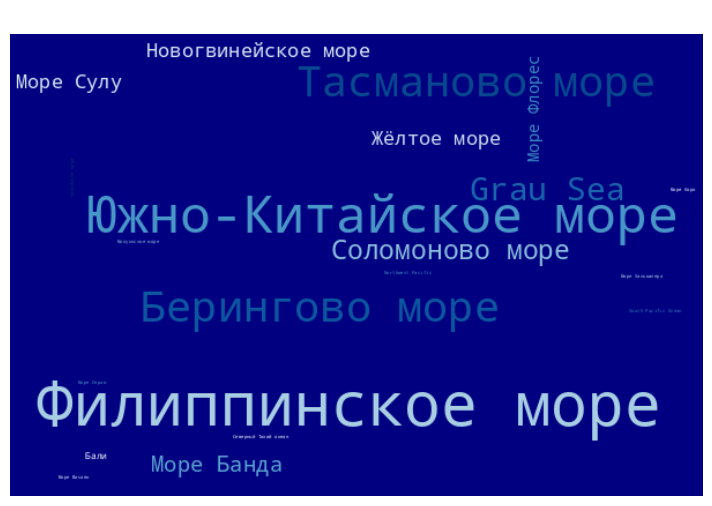

/tmp/ipykernel_10989/1286537452.py:82: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


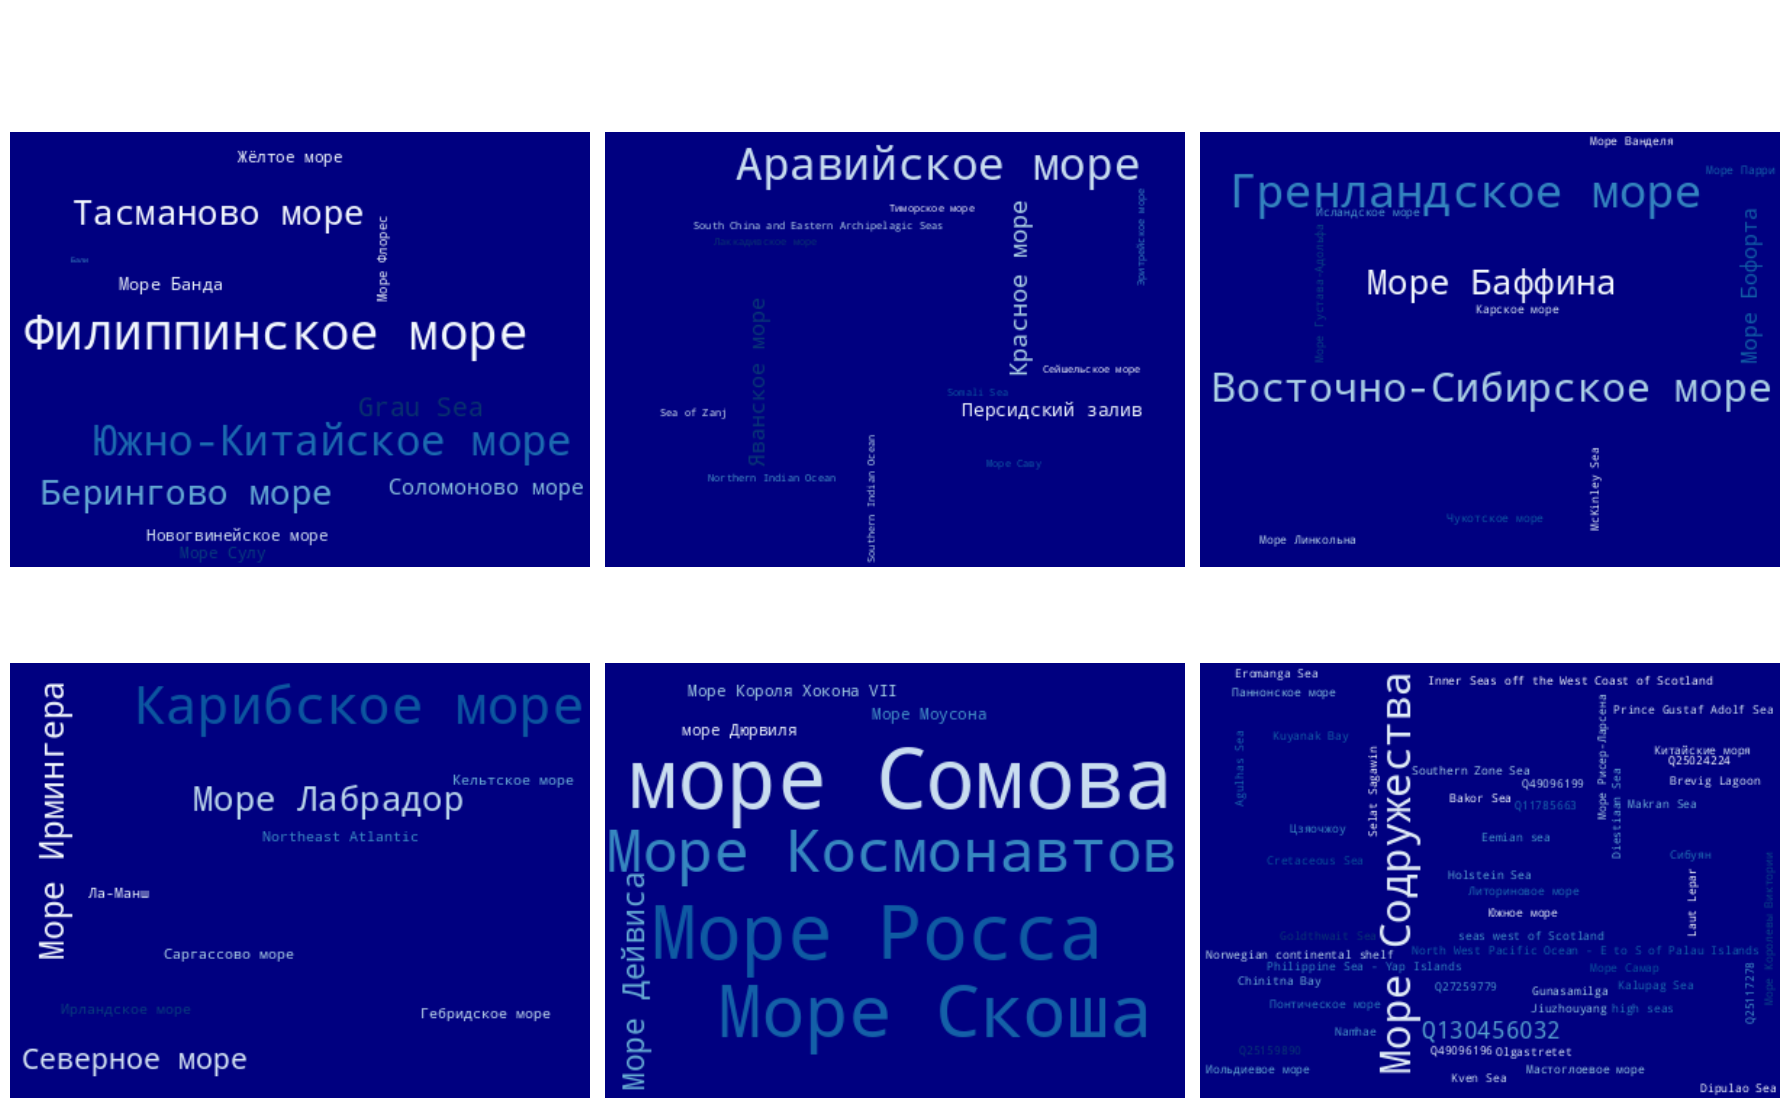

/tmp/ipykernel_10989/1286537452.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_10989/1286537452.py:177: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10989/1286537452.py:178: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.savefig('viz2_sea_wordcloud.png', dpi=150, bbox_inches='tight', facecolor='navy')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


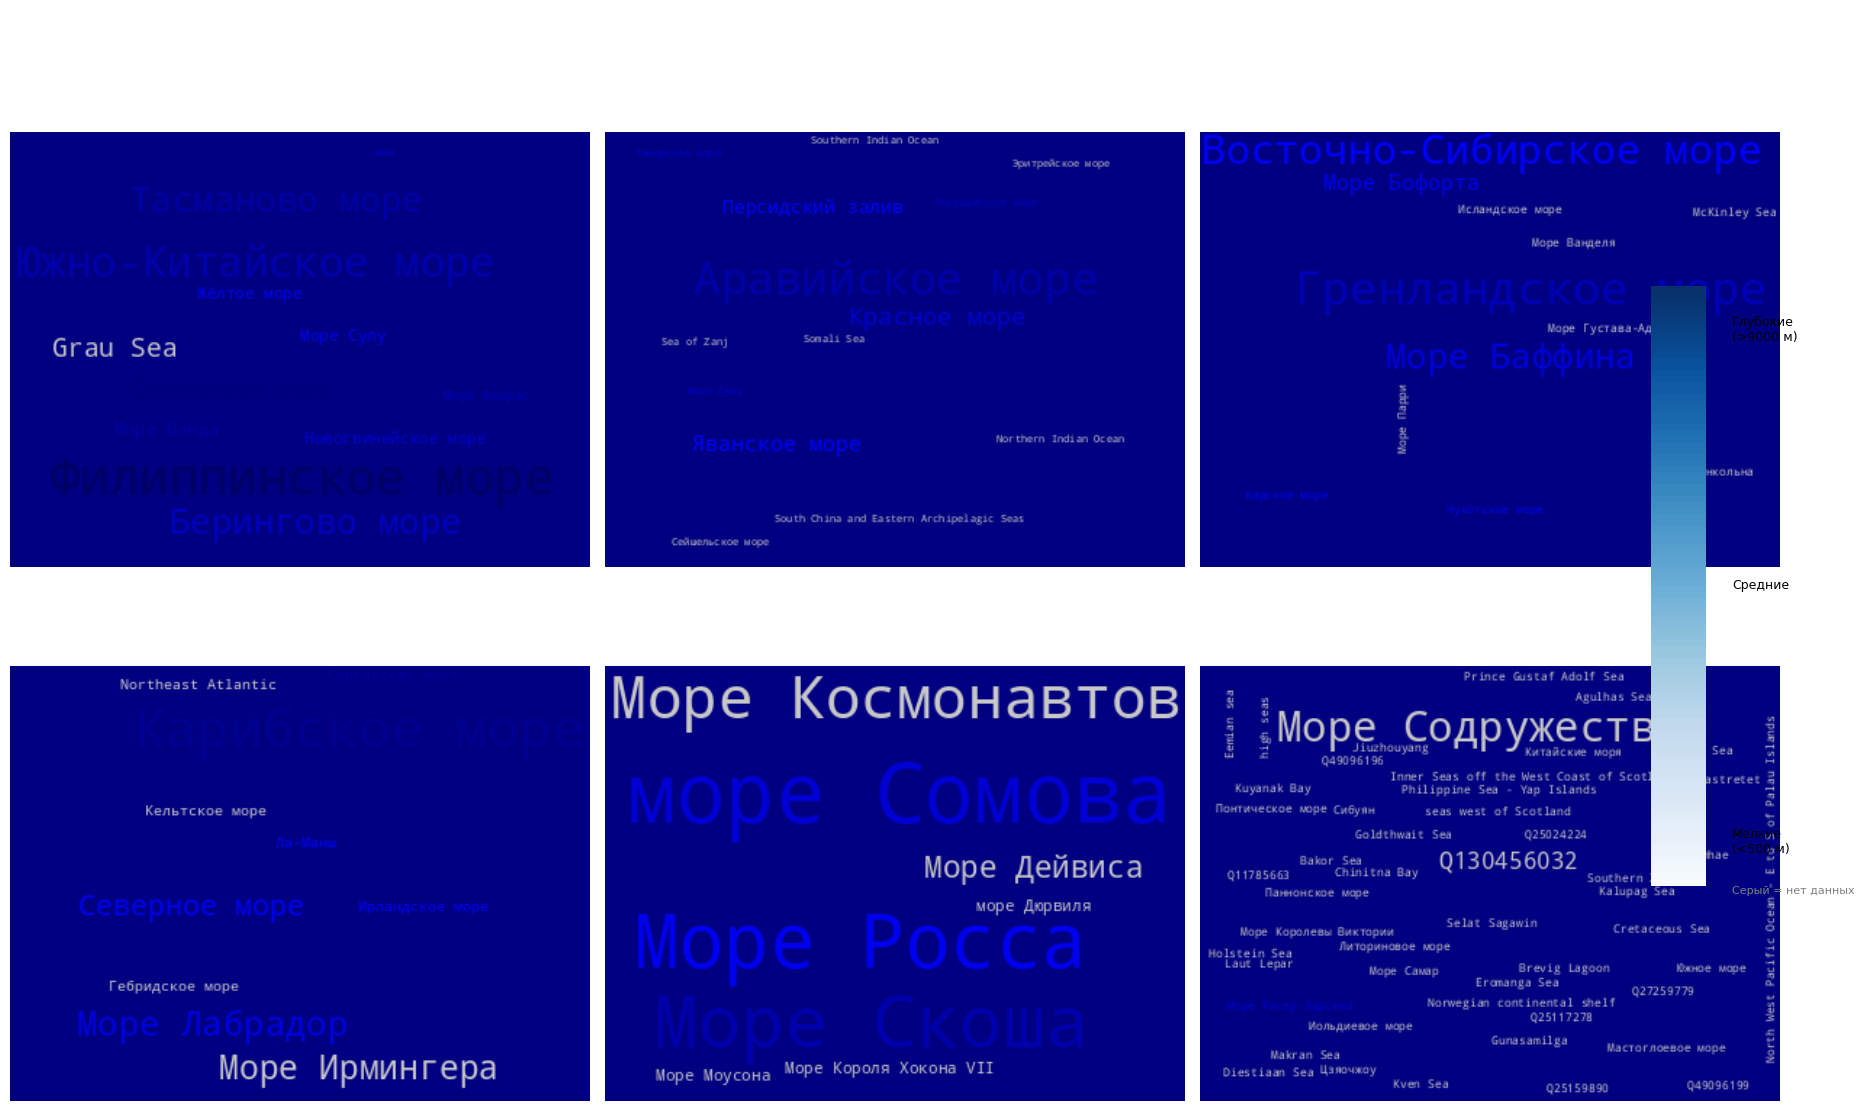

Найдено морей с дубликатами: 27

Примеры:
                sea                         ocean                                     URL
Южно-Китайское море                   Тихий океан   http://www.wikidata.org/entity/Q37660
Южно-Китайское море                Китайские моря   http://www.wikidata.org/entity/Q37660
     Карибское море            Северная Атлантика    http://www.wikidata.org/entity/Q1247
     Карибское море Американское Средиземное море    http://www.wikidata.org/entity/Q1247
  Гренландское море      Северный Ледовитый океан  http://www.wikidata.org/entity/Q132868
  Гренландское море      Северный Ледовитый океан  http://www.wikidata.org/entity/Q132868
           Grau Sea                   Тихий океан http://www.wikidata.org/entity/Q2835799
           Grau Sea           South Pacific Ocean http://www.wikidata.org/entity/Q2835799
         Море Росса                   Южный океан  http://www.wikidata.org/entity/Q164466
      Море Лазарева           Атлантический океан http://w

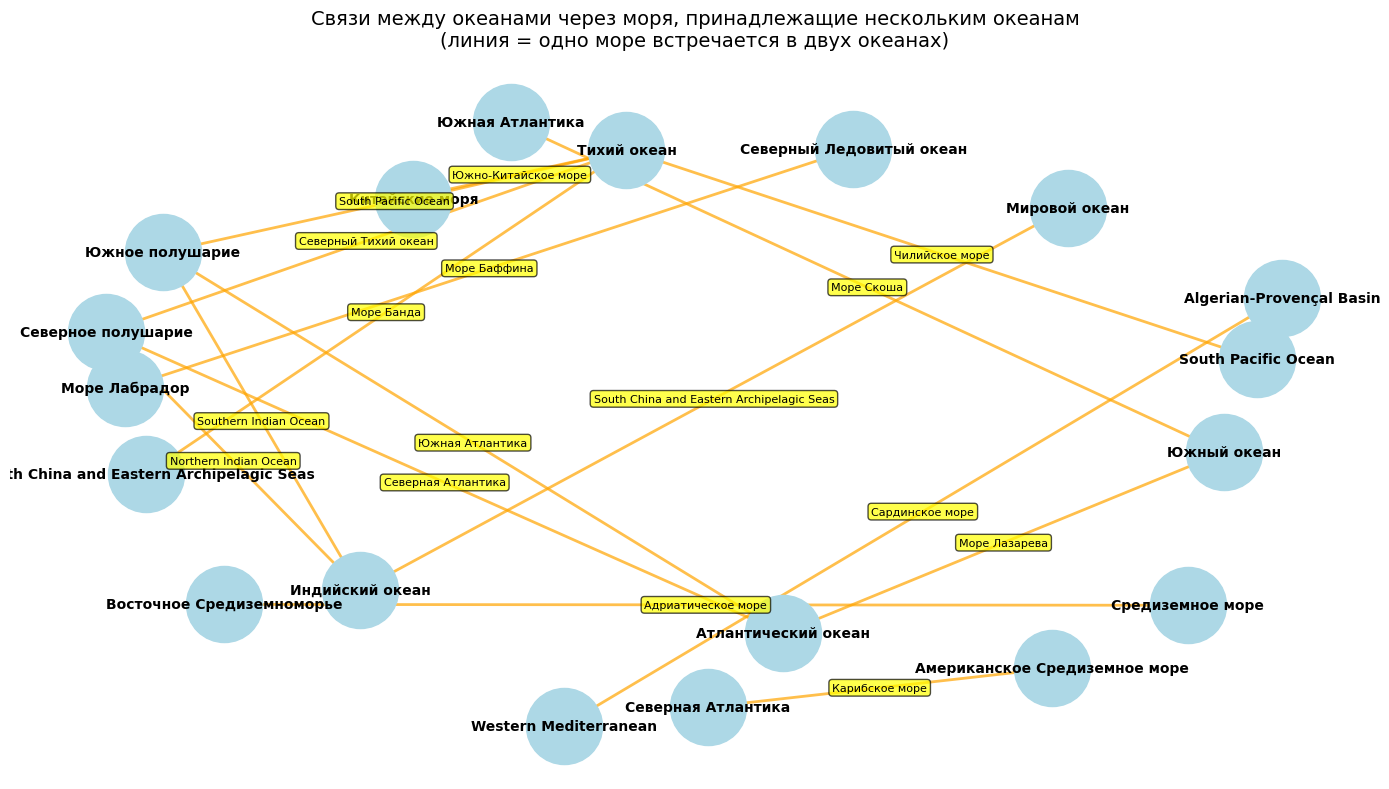

In [2]:
# Установка библиотеки (один раз в начале ноутбука)
!pip install wordcloud -q

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Берём только Тихий океан
df_pacific = df_unique[df_unique['ocean'] == 'Тихий океан'].copy()

# Размер = площадь (или 1, если пусто)
df_pacific['size_for_cloud'] = df_pacific['area'].fillna(1)

# Словарь: {название: размер}
freq = dict(zip(df_pacific['sea'], df_pacific['size_for_cloud']))

wc = WordCloud(width=600, height=400,
               background_color='navy',
               colormap='Blues_r',  # тёмно-синий → светлый
               max_words=50)
wc.generate_from_frequencies(freq)

plt.figure(figsize=(10, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Тихий океан', color='white', fontsize=16)
plt.show()
# Выбираем океаны с достаточным количеством морей (≥3)
oceans_for_clouds = ['Тихий океан', 'Индийский океан', 'Северный Ледовитый океан',
                      'Северная Атлантика', 'Южный океан']

# Добавляем категорию "Неизвестный океан" (63 моря без океана)
df_unknown = df_unique[df_unique['ocean'].isna()].copy()
df_unknown['ocean'] = '🌊 Неизвестный океан'
df_unknown['size_for_cloud'] = df_unknown['area'].fillna(1)

# Создаём фигуру с subplot (2 строки, 3 столбца)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()  # Упрощаем индексацию

for idx, ocean in enumerate(oceans_for_clouds + ['🌊 Неизвестный океан']):
    if idx >= 6:  # У нас 6 океанов (5 известных + неизвестный)
        break

    # Выбираем моря для текущего океана
    if ocean == '🌊 Неизвестный океан':
        df_ocean = df_unknown
    else:
        df_ocean = df_unique[df_unique['ocean'] == ocean].copy()
        df_ocean['size_for_cloud'] = df_ocean['area'].fillna(1)

    if len(df_ocean) == 0:
        axes[idx].text(0.5, 0.5, f'Нет данных\n{ocean}',
                       ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].axis('off')
        continue

    # Создаём словарь частот
    freq = dict(zip(df_ocean['sea'], df_ocean['size_for_cloud']))

    # Генерируем облако слов
    wc = WordCloud(width=400, height=300,
                   background_color='navy',
                   colormap='Blues_r',
                   max_words=50,
                   relative_scaling=0.5)  # Размер слов пропорционален площади
    wc.generate_from_frequencies(freq)

    # Отображаем
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'{ocean}\n(n={len(df_ocean)} морей)',
                        color='white', fontsize=12, pad=10)

# Убираем пустые subplot'ы
for idx in range(len(oceans_for_clouds) + 1, 6):
    axes[idx].axis('off')

plt.suptitle('Облака морей по океанам\n(размер слова = площадь моря, цвет = глубина пока фиксирован)',
             fontsize=16, color='white', y=0.98)
plt.tight_layout()
plt.show()
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

def get_color_by_depth(word, font_size, position, orientation, random_state=None, **kwargs):
    """
    Функция цвета для WordCloud.
    Чем больше глубина - тем темнее синий.
    """
    # Получаем глубину для текущего моря
    depth_val = depth_dict.get(word, None)

    if depth_val is None or pd.isna(depth_val):
        # Нет данных о глубине - светло-серый
        return (200, 200, 200)  # RGB для светло-серого
    else:
        # Нормализуем глубину: max_depth = 10911 м (Филиппинское море)
        # Чем больше глубина, тем темнее синий
        normalized = min(depth_val / 10911, 1.0)
        # От светлого (200, 200, 255) до тёмно-синего (0, 0, 100)
        blue_intensity = int(100 + (1 - normalized) * 155)
        return (0, 0, blue_intensity)

# Создаём словарь глубин для всех морей
depth_dict = dict(zip(df_unique['sea'], df_unique['depth']))

# Функция для создания облака с цветом по глубине
def create_wordcloud_with_depth(df_ocean, ocean_name):
    """Создаёт облако слов с цветом по глубине"""
    df_ocean = df_ocean.copy()
    df_ocean['size_for_cloud'] = df_ocean['area'].fillna(1)
    freq = dict(zip(df_ocean['sea'], df_ocean['size_for_cloud']))

    wc = WordCloud(width=400, height=300,
                   background_color='navy',
                   max_words=50,
                   relative_scaling=0.5,
                   color_func=get_color_by_depth)
    wc.generate_from_frequencies(freq)
    return wc

# Создаём облака для каждого океана
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

oceans_list = ['Тихий океан', 'Индийский океан', 'Северный Ледовитый океан',
               'Северная Атлантика', 'Южный океан', '🌊 Неизвестный океан']

for idx, ocean in enumerate(oceans_list):
    if idx >= 6:
        break

    if ocean == '🌊 Неизвестный океан':
        df_ocean = df_unknown
    else:
        df_ocean = df_unique[df_unique['ocean'] == ocean].copy()
        df_ocean['size_for_cloud'] = df_ocean['area'].fillna(1)

    if len(df_ocean) == 0:
        axes[idx].text(0.5, 0.5, f'Нет данных\n{ocean}',
                       ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].axis('off')
        continue

    # Создаём облако
    wc = create_wordcloud_with_depth(df_ocean, ocean)

    # Отображаем
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')

    # Подсчитываем статистику по глубине
    depths = df_ocean['depth'].dropna()
    if len(depths) > 0:
        depth_info = f'\n(глубина: {depths.min():.0f}-{depths.max():.0f} м)'
    else:
        depth_info = '\n(нет данных о глубине)'

    axes[idx].set_title(f'{ocean}\n(n={len(df_ocean)} морей){depth_info}',
                        color='white', fontsize=10, pad=10)

# Легенда цветов
legend_ax = fig.add_axes([0.92, 0.25, 0.03, 0.5])
legend_ax.axis('off')
legend_colors = np.linspace(0, 1, 100).reshape(-1, 1)
legend_ax.imshow(legend_colors, cmap='Blues_r', aspect='auto', extent=[0, 1, 0, 1])
legend_ax.text(1.5, 0.95, 'Глубокие\n(>9000 м)', fontsize=9, va='top')
legend_ax.text(1.5, 0.5, 'Средние', fontsize=9, va='center')
legend_ax.text(1.5, 0.05, 'Мелкие\n(<500 м)', fontsize=9, va='bottom')
legend_ax.text(1.5, 0.0, 'Серый = нет данных', fontsize=8, va='top', color='gray')

plt.suptitle('Облака морей по океанам\n(размер = площадь, цвет = глубина: от голубого до тёмно-синего)',
             fontsize=16, color='white', y=0.98)
plt.tight_layout()
plt.savefig('viz2_sea_wordcloud.png', dpi=150, bbox_inches='tight', facecolor='navy')
plt.show()
# Находим моря-дубликаты (принадлежат нескольким океанам)
duplicate_seas = df_oceans_clean[df_oceans_clean.duplicated(subset='URL', keep=False)]
print(f"Найдено морей с дубликатами: {duplicate_seas['sea'].nunique()}")
print("\nПримеры:")
print(duplicate_seas[['sea', 'ocean', 'URL']].head(10).to_string(index=False))

# Если есть дубликаты, строим сетевую визуализацию
if len(duplicate_seas) > 0:
    import networkx as nx
    import matplotlib.patches as mpatches

    # Создаём граф: узлы = моря, связи между разными океанами
    G = nx.Graph()

    for sea_name, group in duplicate_seas.groupby('sea'):
        oceans = group['ocean'].unique()
        if len(oceans) > 1:
            # Добавляем связи между океанами для этого моря
            for i in range(len(oceans)):
                for j in range(i+1, len(oceans)):
                    G.add_edge(oceans[i], oceans[j], sea=sea_name)

    # Визуализация графа
    plt.figure(figsize=(14, 8))
    pos = nx.spring_layout(G, k=2, seed=42)

    # Рисуем узлы (океаны)
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=3000)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    # Рисуем рёбра (линии между океанами) с подписями морей
    for edge in G.edges(data=True):
        sea_name = edge[2]['sea']
        nx.draw_networkx_edges(G, pos, edgelist=[(edge[0], edge[1])],
                               width=2, alpha=0.7, edge_color='orange')

        # Добавляем подпись моря в середине ребра
        x_mid = (pos[edge[0]][0] + pos[edge[1]][0]) / 2
        y_mid = (pos[edge[0]][1] + pos[edge[1]][1]) / 2
        plt.text(x_mid, y_mid, sea_name, fontsize=8, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.7))

    plt.title('Связи между океанами через моря, принадлежащие нескольким океанам\n(линия = одно море встречается в двух океанах)',
             fontsize=14, pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('viz2_sea_connections.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Моря-дубликаты не найдены (у всех морей уникальный океан)")
